In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
GROQ_MODEL=os.getenv("GROQ_MODEL")

llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY)

In [3]:
class JokeState():
    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):
    topic = state["topic"]
    
    prompt = f"Generate the joke on this topic {topic}."
    
    response = llm.invoke(prompt).content
    
    return {"joke": response}

In [5]:
def explain_joke(state: JokeState):
    
    topic = state["topic"]
    joke = state["joke"]
    
    prompt = f"Explain the the joke on this topic {topic} and the actual joke is this:\n {joke}"
    
    response = llm.invoke(prompt).content
    
    return {"explanation": response}

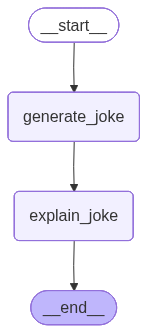

In [6]:
graph = StateGraph(JokeState)
graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkepointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkepointer)

workflow

In [7]:
thread_id = 1
config1 = {"configurable": {"thread_id": thread_id}}

initial_state = {"topic": "Pizza"}

final_state = workflow.invoke(initial_state, config=config1)

print(final_state)

{'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. In everyday language, "feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nHowever, in the context of a pizza, "crusty" has a literal meaning - a pizza has a crust, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s crust (the food) and the phrase "feeling crusty" (the emotional state).\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, and the clever use of wordplay to create a pun. It\'s a lighthearted and cheesy (pun intended) joke that\'s sure to bring a smile to people\'s faces.'}


In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. In everyday language, "feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nHowever, in the context of a pizza, "crusty" has a literal meaning - a pizza has a crust, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s crust (the food) and the phrase "feeling crusty" (the emotional state).\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, and the clever use of wordplay to create a pun. It\'s a lighthearted and cheesy (pun intended) joke that\'s sure to bring a smile to people\'s faces.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16e53d

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. In everyday language, "feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nHowever, in the context of a pizza, "crusty" has a literal meaning - a pizza has a crust, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s crust (the food) and the phrase "feeling crusty" (the emotional state).\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, and the clever use of wordplay to create a pun. It\'s a lighthearted and cheesy (pun intended) joke that\'s sure to bring a smile to people\'s faces.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16e53

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}

result = workflow.invoke({"topic": "Pasta"}, config=config2)

In [ ]:
print(result)

{'topic': 'Pasta', 'joke': 'Why was the pasta in a bad mood?\n\nBecause it was feeling a little "drained" and was worried it would get "sucked" into a bad situation, but in the end, it just needed to "stir" things up and "twirl" its way out of it.', 'explanation': 'A clever joke about pasta. Let\'s break it down:\n\nThe joke starts by setting up the situation: the pasta is in a bad mood. Then, it provides a series of puns related to pasta and cooking to explain why the pasta is feeling down:\n\n1. **"Feeling a little \'drained\'"**: This is a play on words, as pasta is often drained of water after being cooked. However, in this context, "drained" also means feeling emotionally exhausted or depleted.\n2. **"Worried it would get \'sucked\' into a bad situation"**: Another pasta-related pun, as a vacuum or a suction force is often used to drain pasta. Here, "sucked" also implies being pulled into a difficult or unpleasant situation.\n3. **"Needed to \'stir\' things up"**: Stirring is a co

In [16]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A delicious joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "feeling a little crusty" in a punny way. In everyday language, "feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nHowever, in the context of a pizza, "crusty" has a literal meaning - a pizza has a crust, which is the outer layer of the bread. So, the joke is making a clever connection between the pizza\'s crust (the food) and the phrase "feeling crusty" (the emotional state).\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase, and the clever use of wordplay to create a pun. It\'s a lighthearted and cheesy (pun intended) joke that\'s sure to bring a smile to people\'s faces.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16e53d

In [17]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Pasta', 'joke': 'Why was the pasta in a bad mood?\n\nBecause it was feeling a little "drained" and was worried it would get "sucked" into a bad situation, but in the end, it just needed to "stir" things up and "twirl" its way out of it.', 'explanation': 'A clever joke about pasta. Let\'s break it down:\n\nThe joke starts by setting up the situation: the pasta is in a bad mood. Then, it provides a series of puns related to pasta and cooking to explain why the pasta is feeling down:\n\n1. **"Feeling a little \'drained\'"**: This is a play on words, as pasta is often drained of water after being cooked. However, in this context, "drained" also means feeling emotionally exhausted or depleted.\n2. **"Worried it would get \'sucked\' into a bad situation"**: Another pasta-related pun, as a vacuum or a suction force is often used to drain pasta. Here, "sucked" also implies being pulled into a difficult or unpleasant situation.\n3. **"Needed to \'stir\' things up